## Import Data


In [12]:
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

In [19]:
pd.options.display.float_format = '{:.2f}'.format
df = pd.read_parquet('yellow_tripdata_2024-01.parquet')
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.00,1.72,1.00,N,186,79,2,17.70,1.00,0.50,0.00,0.00,1.00,22.70,2.50,0.00
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.00,1.80,1.00,N,140,236,1,10.00,3.50,0.50,3.75,0.00,1.00,18.75,2.50,0.00
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.00,4.70,1.00,N,236,79,1,23.30,3.50,0.50,3.00,0.00,1.00,31.30,2.50,0.00
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.00,1.40,1.00,N,79,211,1,10.00,3.50,0.50,2.00,0.00,1.00,17.00,2.50,0.00
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.00,0.80,1.00,N,211,148,1,7.90,3.50,0.50,3.20,0.00,1.00,16.10,2.50,0.00


## Describe data

In [20]:
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
count,2964624.00,2964624,2964624,2824462.00,2964624.00,2824462.00,2964624.00,2964624.00,2964624.00,2964624.00,2964624.00,2964624.00,2964624.00,2964624.00,2964624.00,2964624.00,2824462.00,2824462.00
mean,1.75,2024-01-17 00:46:36.431092,2024-01-17 01:02:13.208130,1.34,3.65,2.07,166.02,165.12,1.16,18.18,1.45,0.48,3.34,0.53,0.98,26.80,2.26,0.14
min,1.00,2002-12-31 22:59:39,2002-12-31 23:05:41,0.00,0.00,1.00,1.00,1.00,0.00,-899.00,-7.50,-0.50,-80.00,-80.00,-1.00,-900.00,-2.50,-1.75
25%,2.00,2024-01-09 15:59:19.750000,2024-01-09 16:16:23,1.00,1.00,1.00,132.00,114.00,1.00,8.60,0.00,0.50,1.00,0.00,1.00,15.38,2.50,0.00
50%,2.00,2024-01-17 10:45:37.500000,2024-01-17 11:03:51.500000,1.00,1.68,1.00,162.00,162.00,1.00,12.80,1.00,0.50,2.70,0.00,1.00,20.10,2.50,0.00
75%,2.00,2024-01-24 18:23:52.250000,2024-01-24 18:40:29,1.00,3.11,1.00,234.00,234.00,1.00,20.50,2.50,0.50,4.12,0.00,1.00,28.56,2.50,0.00
max,6.00,2024-02-01 00:01:15,2024-02-02 13:56:52,9.00,312722.30,99.00,265.00,265.00,4.00,5000.00,14.25,4.00,428.00,115.92,1.00,5000.00,2.50,1.75
std,0.43,NaN,NaN,0.85,225.46,9.82,63.62,69.32,0.58,18.95,1.80,0.12,3.90,2.13,0.22,23.39,0.82,0.49


## Data Preprocessing / Transformation
### Feature Engineering

1) The dataset has columns "pep_pickup_datetime" "tpep_dropoff_datetime" for that creatig new column Time slot with (Morning,Evening,night,afternoon) for better analysis using ColumnTransformer

In [9]:
class TimeSlotTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    
    def transform(self, X, y=None):
        time_slots = X.apply(lambda x: self.get_time_slot(x['tpep_pickup_datetime']), axis=1)
        return np.array(time_slots).reshape(-1, 1)
    
    def get_time_slot(self, time):
        if 5 <= time.hour < 12:
            return 'Morning'
        elif 12 <= time.hour < 17:
            return 'Afternoon'
        elif 17 <= time.hour < 21:
            return 'Evening'
        else:
            return 'Night'

pipeline = Pipeline(steps=[
    ('time_slot_transformer', ColumnTransformer(
        transformers=[
            ('time_slot', TimeSlotTransformer(), ['tpep_pickup_datetime'])
        ],
        remainder='drop'  # This drops other columns not specified in transformers
    ))
])
time_slots = pipeline.fit_transform(df)
time_slots

array([['Night'],
       ['Night'],
       ['Night'],
       ...,
       ['Night'],
       ['Night'],
       ['Night']], dtype=object)

2) Creating a separate column which has the data for trip distance (short, long, medium)
but the the column has outliers in it and random values like 300,000 miles 
so creating a caping thershold 278 miles because one rows has 277 miles with correct data 

## Percentile Outlier detection 
- Chose this one because it dosent change the count 

In [21]:
cap_threshold = df['trip_distance'].quantile(0.99)
# cap_threshold = 278
df['trip_distance'] = df['trip_distance'].clip(upper=cap_threshold)
df['trip_distance'].describe()



count   2964624.00
mean          3.19
std           4.14
min           0.00
25%           1.00
50%           1.68
75%           3.11
max          20.00
Name: trip_distance, dtype: float64

## Removing Outlier using DBSACN
- Not suitable outlier detection method due to huge row size

In [ ]:
# Assuming df is your DataFrame and 'trip_distance' is the column of interest
# X = df[['trip_distance']].values
# df_subset = df[['trip_distance']].sample(n=10000, random_state=42)
# X = df_subset.values
# Initialize DBSCAN
# eps is set to a small value to detect outliers, you may need to adjust it
# min_samples is set to a small value to ensure we detect outliers effectively
# dbscan = DBSCAN(eps=0.5, min_samples=5)

# Fit the model
# dbscan.fit(X)

# Get the labels (-1 indicates noise)
# labels = dbscan.labels_
# labels
# Filter out the outliers
# X_cleaned = X[labels != -1]
# df_trip_distance_cleaned = pd.DataFrame(X_cleaned, columns=['trip_distance'])
# df_trip_distance_cleaned.describe()
# Optionally, you can reset the index
# df_cleaned.reset_index(drop=True, inplace=True)

# Display the cleaned DataFrame
# df_cleaned.describe()

## Isolation Forest
- reduced the overall count

In [6]:
X = df[['trip_distance']].values

# Initialize Isolation Forest
iso_forest = IsolationForest(contamination=0.01, random_state=42)

# Fit the model
iso_forest.fit(X)

# Get the outlier predictions (-1 indicates outliers)
outliers = iso_forest.predict(X)

# Filter out the outliers
X_cleaned = X[outliers != -1]

# Optionally, convert the cleaned data back to a DataFrame
df_trip_distance_cleaned = pd.DataFrame(X_cleaned, columns=['trip_distance'])

# Display the cleaned DataFrame
print(df_trip_distance_cleaned.describe())

       trip_distance
count     2935661.00
mean            3.02
std             3.81
min             0.00
25%             0.99
50%             1.66
75%             3.04
max            20.17


## MinMaxScaler and StandardScaler
- not choosen due to arrangement between 0 and 1

In [15]:
trip_distance1 = df[['trip_distance']]

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Fit and transform the data
trip_distance_normalized = scaler.fit_transform(trip_distance1)

# Convert back to DataFrame
df_trip_distance_normalized = pd.DataFrame(trip_distance_normalized, columns=['trip_distance'])

# Display the normalized DataFrame
print(df_trip_distance_normalized.describe())

       trip_distance
count     2964624.00
mean            0.00
std             0.00
min             0.00
25%             0.00
50%             0.00
75%             0.00
max             1.00


In [18]:
# Assuming df is your DataFrame and 'trip_distance' is the column of interest
trip_distance2 = df[['trip_distance']]

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform the data
trip_distance_standardized = scaler.fit_transform(trip_distance2)

# Convert back to DataFrame
df_trip_distance_standardized = pd.DataFrame(trip_distance_standardized, columns=['trip_distance'])

# Display the standardized DataFrame
print(df_trip_distance_standardized.describe())

       trip_distance
count     2964624.00
mean            0.00
std             1.00
min            -0.02
25%            -0.01
50%            -0.01
75%            -0.00
max          1387.01


### Visualizing

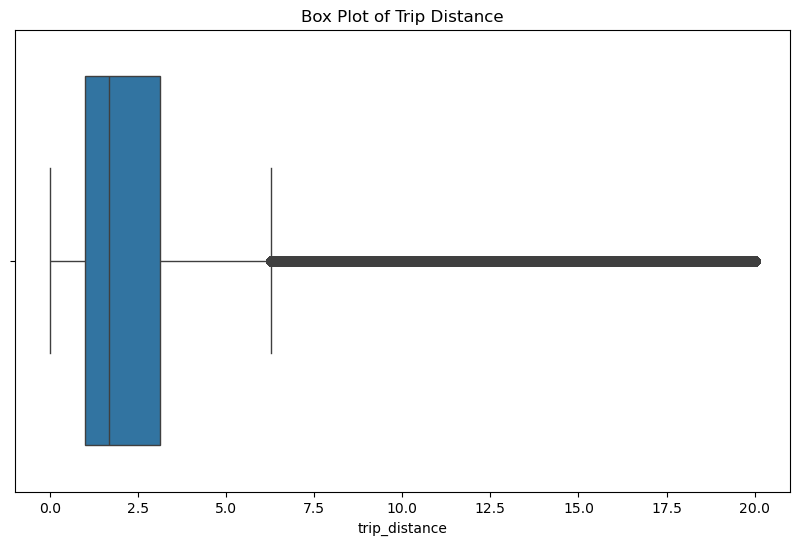

In [22]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['trip_distance'])
plt.title('Box Plot of Trip Distance')
plt.show()